# MoE-RenalSAM-CG — Notebook 01: Dataset Verification & Mask Extraction

## What this notebook does

```
Kaggle Dataset (8737 images, NO annotations)
        ↓
   Feed into segmentation models
        ↓
   Models produce predicted masks
        ↓
   Compare against Ground Truth
        ↓
RenSeg Dataset (same 8737 images, WITH expert red contour annotations)
   → Extract binary masks from red contours  ← THIS NOTEBOOK DOES THIS
```

**Steps:**
1. Verify both datasets contain the same images (filename match)
2. Visually inspect Kaggle images and RenSeg annotations
3. Extract binary masks from RenSeg red contours (red pixel → flood fill → binary PNG)
4. Validate extracted masks per class
5. Save binary masks as ground truth for evaluation

**Outputs:**
- `data/processed/renseg_masks/{Normal,Tumor,Stone}/` — binary mask PNGs
- `data/processed/mask_extraction_report.json`

## 0. Imports

In [3]:
import os, json, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import cv2
import scipy.ndimage as ndi
warnings.filterwarnings('ignore')

# Move to project root if running from inside notebooks/ or preprocessing/
if not (Path.cwd() / 'data').exists():
    os.chdir(Path.cwd().parent)
print('Working directory:', Path.cwd())

def header(msg): print(f'\n{"="*65}\n  {msg}\n{"="*65}')
def ok(msg):     print(f'  [ OK ]  {msg}')
def info(msg):   print(f'  [INFO]  {msg}')
def warn(msg):   print(f'  [WARN]  {msg}')
def err(msg):    print(f'  [ERR ]  {msg}')

Working directory: D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG


## 1. Configuration

In [4]:
KAGGLE_ROOT  = Path('data/raw/kaggle')           # unannotated CT images
RENSEG_ROOT  = Path('data/raw/renseg')           # same images + expert red contour annotations
MASKS_ROOT   = Path('data/processed/renseg_masks')  # output binary masks
REPORTS_DIR  = Path('data/processed')

CLASSES  = ['Normal', 'Tumor', 'Stone']
IMG_EXTS = {'.jpg', '.jpeg', '.png'}

# Red contour detection thresholds
# A pixel is 'red' if:  R - G > RED_DOMINANCE  AND  R - B > RED_DOMINANCE  AND  R > RED_MIN
RED_DOMINANCE = 60    # how much R must exceed G and B
RED_MIN       = 100   # minimum R value

# Create output dirs
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
for cls in CLASSES:
    (MASKS_ROOT / cls).mkdir(parents=True, exist_ok=True)

header('Configuration')
info(f'Kaggle (input)  : {KAGGLE_ROOT.resolve()}')
info(f'RenSeg (GT)     : {RENSEG_ROOT.resolve()}')
info(f'Masks output    : {MASKS_ROOT.resolve()}')
info(f'Classes         : {CLASSES}')

for root, label in [(KAGGLE_ROOT, 'Kaggle'), (RENSEG_ROOT, 'RenSeg')]:
    if root.exists(): ok(f'{label} root found')
    else:             err(f'{label} root NOT found: {root}')


  Configuration
  [INFO]  Kaggle (input)  : D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\data\raw\kaggle
  [INFO]  RenSeg (GT)     : D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\data\raw\renseg
  [INFO]  Masks output    : D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\data\processed\renseg_masks
  [INFO]  Classes         : ['Normal', 'Tumor', 'Stone']
  [ OK ]  Kaggle root found
  [ OK ]  RenSeg root found


## 2. Dataset Verification — Confirm Both Datasets Match

In [5]:
def get_filenames(root: Path, classes: list) -> dict:
    return {
        cls: {p.name for p in (root/cls).iterdir()
              if p.suffix.lower() in IMG_EXTS}
        if (root/cls).exists() else set()
        for cls in classes
    }

def get_filepaths(root: Path, classes: list) -> dict:
    return {
        cls: sorted(p for p in (root/cls).iterdir()
                    if p.suffix.lower() in IMG_EXTS)
        if (root/cls).exists() else []
        for cls in classes
    }

header('Dataset Verification')

kaggle_names  = get_filenames(KAGGLE_ROOT, CLASSES)
renseg_names  = get_filenames(RENSEG_ROOT, CLASSES)
kaggle_files  = get_filepaths(KAGGLE_ROOT, CLASSES)
renseg_files  = get_filepaths(RENSEG_ROOT, CLASSES)

print(f'\n  {"Class":<10} {"Kaggle":<10} {"RenSeg":<10} {"Match":<10} {"Status"}')
print(f'  {"-"*55}')

all_match = True
for cls in CLASSES:
    k = len(kaggle_names[cls])
    r = len(renseg_names[cls])
    common = kaggle_names[cls] & renseg_names[cls]
    match  = len(common)
    status = '✓ PERFECT' if k == r == match else '⚠ MISMATCH'
    if k != r: all_match = False
    print(f'  {cls:<10} {k:<10} {r:<10} {match:<10} {status}')

print(f'  {"-"*55}')
total_k = sum(len(v) for v in kaggle_names.values())
total_r = sum(len(v) for v in renseg_names.values())
print(f'  {"TOTAL":<10} {total_k:<10} {total_r:<10}')
print()

if all_match:
    ok(f'Both datasets have identical files — {total_k} images per dataset.')
    ok('Kaggle = model INPUT.  RenSeg = GROUND TRUTH for evaluation.')
else:
    warn('Count mismatch detected. Check folder contents.')


  Dataset Verification

  Class      Kaggle     RenSeg     Match      Status
  -------------------------------------------------------
  Normal     5077       5077       5077       ✓ PERFECT
  Tumor      2283       2283       2283       ✓ PERFECT
  Stone      1377       1377       1377       ✓ PERFECT
  -------------------------------------------------------
  TOTAL      8737       8737      

  [ OK ]  Both datasets have identical files — 8737 images per dataset.
  [ OK ]  Kaggle = model INPUT.  RenSeg = GROUND TRUTH for evaluation.


## 3. Visual Inspection

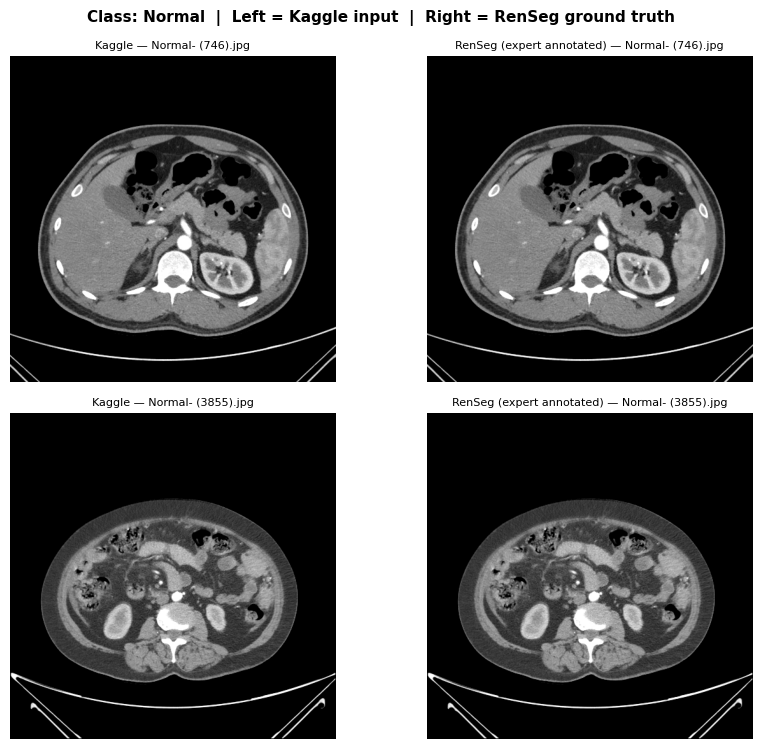

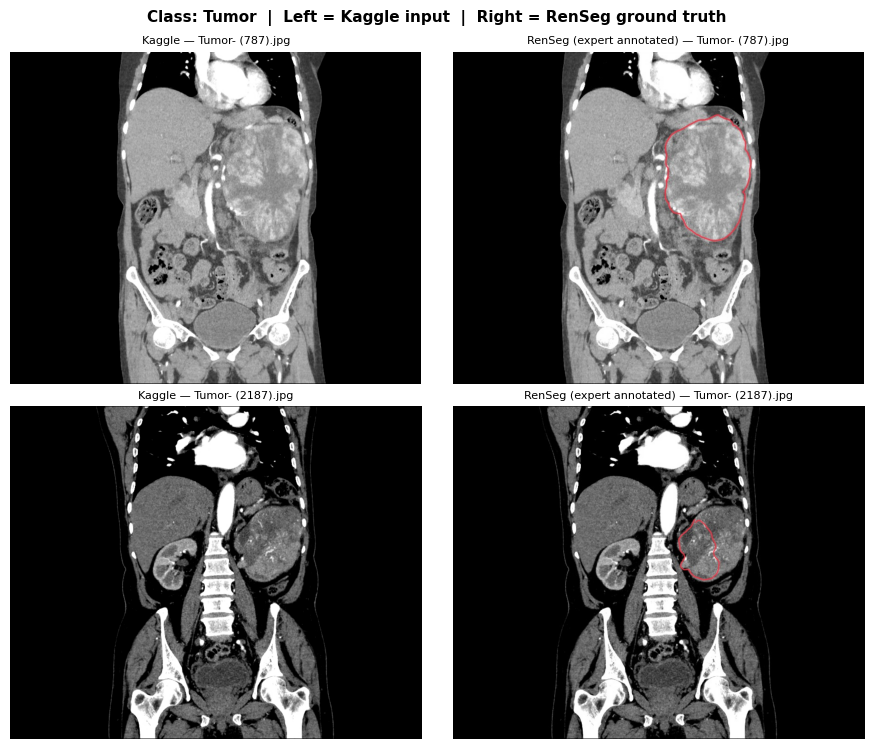

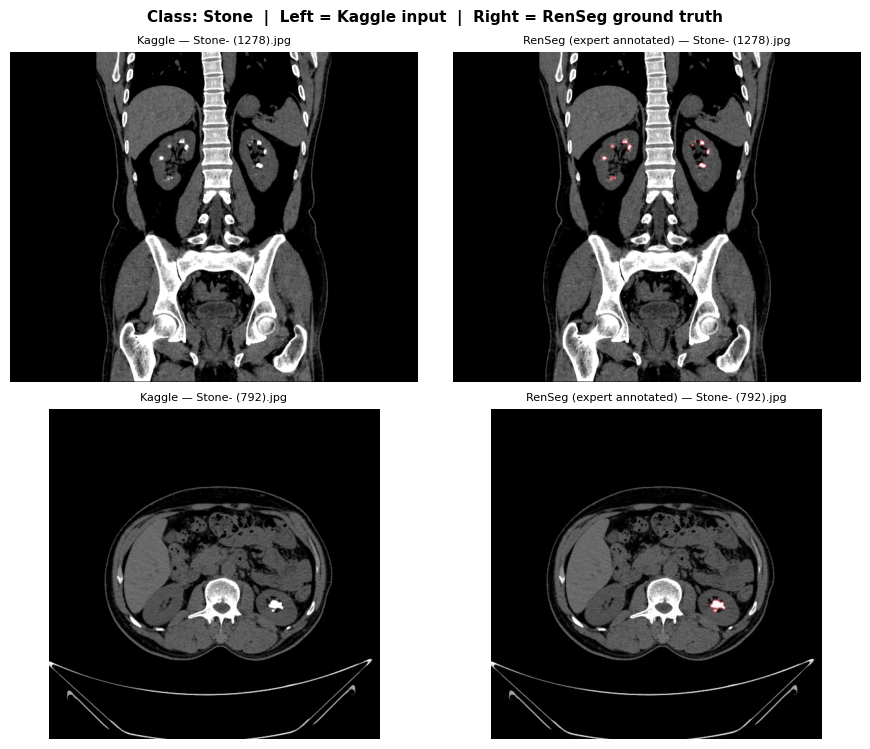

In [6]:
def show_side_by_side(kaggle_files: dict, renseg_files: dict,
                       classes: list, n_per_class: int = 2, seed: int = 7):
    """
    For each class show n_per_class pairs:
    Kaggle raw (grayscale) | RenSeg annotated (colour, red contour visible)
    """
    rng = np.random.default_rng(seed)

    for cls in classes:
        k_files = kaggle_files[cls]
        r_files = renseg_files[cls]
        if not k_files or not r_files:
            warn(f'No files for class: {cls}')
            continue

        # pick same indices from both (they are the same images)
        picks = rng.choice(len(k_files),
                            size=min(n_per_class, len(k_files)),
                            replace=False)

        fig, axes = plt.subplots(len(picks), 2,
                                  figsize=(9, len(picks) * 3.8))
        if len(picks) == 1:
            axes = axes[np.newaxis, :]

        fig.suptitle(f'Class: {cls}  |  Left = Kaggle input  |  Right = RenSeg ground truth',
                     fontsize=11, fontweight='bold')

        for row, idx in enumerate(picks):
            k_img = np.array(Image.open(k_files[idx]).convert('RGB'))
            r_img = np.array(Image.open(r_files[idx]).convert('RGB'))

            axes[row,0].imshow(k_img)
            axes[row,0].set_title(f'Kaggle — {k_files[idx].name}', fontsize=8)
            axes[row,0].axis('off')

            axes[row,1].imshow(r_img)
            axes[row,1].set_title(f'RenSeg (expert annotated) — {r_files[idx].name}', fontsize=8)
            axes[row,1].axis('off')

        plt.tight_layout()
        plt.savefig(REPORTS_DIR / f'inspect_{cls}.png', dpi=130, bbox_inches='tight')
        plt.show()


show_side_by_side(kaggle_files, renseg_files, CLASSES, n_per_class=2)

## 4. Extract Binary Masks from RenSeg Red Contours

**Pipeline per image:**
```
RenSeg image (RGB)
    → detect red pixels  (R - G > 60 AND R - B > 60 AND R > 100)
    → morphological closing  (fill small gaps in contour line)
    → find contours
    → flood fill interior
    → binary mask PNG  (0 = background, 255 = pathology)
```
For **Normal** class: mask will be all-zero (no pathology) — this is correct.

In [7]:
def extract_red_pixels(rgb: np.ndarray) -> np.ndarray:
    """
    Detect red annotation pixels in an RGB image.
    Returns binary mask (H, W) uint8 where 255 = red pixel.
    """
    R = rgb[:,:,0].astype(int)
    G = rgb[:,:,1].astype(int)
    B = rgb[:,:,2].astype(int)
    red_mask = (
        (R - G > RED_DOMINANCE) &
        (R - B > RED_DOMINANCE) &
        (R > RED_MIN)
    )
    return (red_mask * 255).astype(np.uint8)
def red_to_binary_mask(rgb: np.ndarray, class_name: str = 'Unknown') -> np.ndarray:
    h, w   = rgb.shape[:2]
    red_px = extract_red_pixels(rgb)

    if red_px.sum() == 0:
        return np.zeros((h, w), dtype=np.uint8)

    # ── STONE ─────────────────────────────────────────────────────────────────
    if class_name == 'Stone':
        # Moderate closing to connect stroke gaps
        k = np.ones((15, 15), np.uint8)
        strong = cv2.morphologyEx(red_px, cv2.MORPH_CLOSE, k, iterations=2)
        
        # Pad and fill holes so hollow rings become solid blobs
        pad = 20
        padded = np.pad(strong > 0, pad, mode='constant', constant_values=False)
        filled = ndi.binary_fill_holes(padded)
        
        # Remove padding
        result = (filled[pad:-pad, pad:-pad] * 255).astype(np.uint8)
        
        # Safety check: if it filled more than 50% of image, just dilate it instead
        if (result > 0).sum() / (h * w) > 0.50:
            k2 = np.ones((9, 9), np.uint8)
            return cv2.dilate(red_px, k2, iterations=1)
            
        return result

    # ── TUMOR — exact approach from diagnostic column 4 ───────────────────────
    if class_name == 'Tumor':
        # strong closing seals all contour gaps
        k      = np.ones((31, 31), np.uint8)
        strong = cv2.morphologyEx(red_px, cv2.MORPH_CLOSE, k, iterations=3)

        # pad before fill so border-touching rings work correctly
        pad    = 50
        padded = np.pad(strong > 0, pad, mode='constant', constant_values=False)
        filled = ndi.binary_fill_holes(padded)

        # remove padding and convert back
        result = (filled[pad:-pad, pad:-pad] * 255).astype(np.uint8)

        # safety check
        if (result > 0).sum() / (h * w) > 0.50:
            k2 = np.ones((9, 9), np.uint8)
            return cv2.dilate(red_px, k2, iterations=1)

        return result

    # ── NORMAL ────────────────────────────────────────────────────────────────
    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(red_px, cv2.MORPH_CLOSE, kernel, iterations=2)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros((h, w), dtype=np.uint8)

    filled = np.zeros((h, w), dtype=np.uint8)
    for cnt in contours:
        single = np.zeros((h, w), dtype=np.uint8)
        cv2.drawContours(single, [cnt], -1, 255, thickness=cv2.FILLED)
        dist             = cv2.distanceTransform(single, cv2.DIST_L2, 5)
        _, _, _, max_loc = cv2.minMaxLoc(dist)
        cx, cy           = max_loc
        flood            = single.copy()
        mask_ff          = np.zeros((h + 2, w + 2), dtype=np.uint8)
        cv2.floodFill(flood, mask_ff, (cx, cy), 255)
        filled           = cv2.bitwise_or(filled, flood)

    return filled
        # Moderate closing to connect stroke gaps and find bounding boxes\n        k = np.ones((15, 15), np.uint8)\n        strong = cv2.morphologyEx(red_px, cv2.MORPH_CLOSE, k, iterations=2)\n        \n        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)\n        calc = np.zeros_like(red_px)\n        \n        nlbl, lbl, st, _ = cv2.connectedComponentsWithStats(strong, 8)\n        for i in range(1, nlbl):\n            x, y, w_box, h_box = st[i, 0], st[i, 1], st[i, 2], st[i, 3]\n            area = st[i, cv2.CC_STAT_AREA]\n            if area < 1: continue\n            \n            roi = gray[y:y+h_box, x:x+w_box]\n            if roi.size == 0: continue\n            \n            # Apply Otsu to extract pure calcification within the expert's bounding box\n            _, rb = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)\n            \n            # Place in the mask\n            calc[y:y+h_box, x:x+w_box] = np.maximum(calc[y:y+h_box, x:x+w_box], rb)\n            \n        return calc\n\n

In [8]:
def test_extraction(cls: str):
    files = renseg_files[cls]
    if not files:
        warn(f'No files for {cls}')
        return

    rng = np.random.default_rng(42)
    for _ in range(50):
        pick = files[rng.integers(0, len(files))]
        rgb  = np.array(Image.open(pick).convert('RGB'))
        red  = extract_red_pixels(rgb)
        if red.sum() > 0:
            break

    # ── pass class_name so thresholds are correct ─────────────────────────────
    mask = red_to_binary_mask(rgb, class_name=cls)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'Mask extraction — Class: {cls} | {pick.name}', fontweight='bold')

    axes[0].imshow(rgb)
    axes[0].set_title('RenSeg (original)', fontsize=9)
    axes[0].axis('off')

    axes[1].imshow(extract_red_pixels(rgb), cmap='Reds')
    axes[1].set_title('Red contour pixels', fontsize=9)
    axes[1].axis('off')

    axes[2].imshow(mask, cmap='gray')
    axes[2].set_title('Final Mask (Filled)', fontsize=9)
    axes[2].axis('off')

    overlay = rgb.copy()
    overlay[mask > 0] = [0, 255, 0]
    axes[3].imshow(overlay)
    axes[3].set_title('Overlay', fontsize=9)
    axes[3].axis('off')

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f'extract_test_{cls}.png', dpi=120)
    plt.show()
    
    info(f'{cls}: red_pixels={extract_red_pixels(rgb).sum()//255}  filled_mask={(mask>0).sum()} px  fill%={((mask>0).sum()/(mask.shape[0]*mask.shape[1]))*100:.2f}%')


## 5. Process All RenSeg Images → Save Binary Masks

In [9]:
from tqdm.notebook import tqdm

def process_all_renseg(renseg_files: dict, masks_root: Path) -> dict:
    """
    Extract binary masks from all RenSeg images.
    Saves: masks_root/{class}/{stem}_mask.png
    Returns per-class statistics.
    """
    stats = {}

    for cls in CLASSES:
        files   = renseg_files[cls]
        out_dir = masks_root / cls
        out_dir.mkdir(parents=True, exist_ok=True)

        n_with_annotation = 0
        n_empty           = 0
        n_skipped         = 0

        for p in tqdm(files, desc=f'Extracting {cls}'):
            out_path = out_dir / f'{p.stem}_mask.png'

            if out_path.exists():   # resume support
                n_skipped += 1
                continue

            rgb  = np.array(Image.open(p).convert('RGB'))
            mask = red_to_binary_mask(rgb)

            Image.fromarray(mask).save(out_path)

            if mask.sum() > 0:
                n_with_annotation += 1
            else:
                n_empty += 1

        stats[cls] = {
            'total'            : len(files),
            'with_annotation'  : n_with_annotation,
            'empty_mask'       : n_empty,
            'skipped_existing' : n_skipped,
        }

        info(f'{cls:<10}: '
             f'annotated={n_with_annotation}  '
             f'empty={n_empty}  '
             f'skipped={n_skipped}')

    return stats


header('Extracting Binary Masks from All RenSeg Images')
mask_stats = process_all_renseg(renseg_files, MASKS_ROOT)
ok('All masks saved.')



  Extracting Binary Masks from All RenSeg Images


Extracting Normal:   0%|          | 0/5077 [00:00<?, ?it/s]

  [INFO]  Normal    : annotated=0  empty=5077  skipped=0


Extracting Tumor:   0%|          | 0/2283 [00:00<?, ?it/s]

  [INFO]  Tumor     : annotated=2283  empty=0  skipped=0


Extracting Stone:   0%|          | 0/1377 [00:00<?, ?it/s]

  [INFO]  Stone     : annotated=1376  empty=1  skipped=0
  [ OK ]  All masks saved.


In [10]:
# ── POST-PROCESS: Find all hollow masks and fix them ─────────────────────────
import shutil

header('Finding and fixing hollow Tumor masks')

# Step 1: Find all hollow masks using erosion test
hollow_paths = []

for mask_path in sorted((MASKS_ROOT / 'Tumor').glob('*_mask.png')):
    mask   = np.array(Image.open(mask_path).convert('L'))
    if mask.sum() == 0:
        continue
    eroded = cv2.erode(mask, np.ones((5,5), np.uint8), iterations=3)
    if eroded.sum() == 0:
        hollow_paths.append(mask_path)

info(f'Hollow masks found: {len(hollow_paths)}')

# Step 2: Fix each hollow mask
fixed = failed = 0

for mask_path in tqdm(hollow_paths, desc='Fixing hollow masks'):
    try:
        # find original RenSeg image
        stem    = mask_path.stem.replace('_mask', '')
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png']:
            candidate = RENSEG_ROOT / 'Tumor' / f'{stem}{ext}'
            if candidate.exists():
                img_path = candidate
                break

        if img_path is None:
            warn(f'Original image not found for {stem}')
            failed += 1
            continue

        # extract red pixels from original
        rgb    = np.array(Image.open(img_path).convert('RGB'))
        red_px = extract_red_pixels(rgb)
        h, w   = rgb.shape[:2]

        if red_px.sum() == 0:
            failed += 1
            continue

        # strong close + padded fill_holes (proven to work from diagnostic)
        k      = np.ones((31, 31), np.uint8)
        strong = cv2.morphologyEx(red_px, cv2.MORPH_CLOSE, k, iterations=3)

        pad    = 50
        padded = np.pad(strong > 0, pad, mode='constant', constant_values=False)
        filled = ndi.binary_fill_holes(padded)
        result = (filled[pad:-pad, pad:-pad] * 255).astype(np.uint8)

        # verify result is solid (not hollow)
        eroded_check = cv2.erode(result, np.ones((5,5), np.uint8), iterations=3)
        if eroded_check.sum() == 0 and result.sum() > 0:
            # still hollow — use maximum dilation as absolute last resort
            k2     = np.ones((41, 41), np.uint8)
            strong2 = cv2.dilate(red_px, k2, iterations=3)
            pad2   = 50
            padded2 = np.pad(strong2 > 0, pad2, mode='constant', constant_values=False)
            filled2 = ndi.binary_fill_holes(padded2)
            result  = (filled2[pad2:-pad2, pad2:-pad2] * 255).astype(np.uint8)

        # save fixed mask
        Image.fromarray(result).save(mask_path)
        fixed += 1

    except Exception as e:
        warn(f'Error fixing {mask_path.name}: {e}')
        failed += 1

ok(f'Fixed: {fixed}   Failed: {failed}')

# Step 3: Verify — re-check hollow count
still_hollow = 0
for mask_path in sorted((MASKS_ROOT / 'Tumor').glob('*_mask.png')):
    mask   = np.array(Image.open(mask_path).convert('L'))
    if mask.sum() == 0:
        continue
    eroded = cv2.erode(mask, np.ones((5,5), np.uint8), iterations=3)
    if eroded.sum() == 0:
        still_hollow += 1

if still_hollow == 0:
    ok('All hollow masks fixed. Zero hollow masks remaining.')
else:
    warn(f'Still hollow: {still_hollow} — check these manually')


  Finding and fixing hollow Tumor masks
  [INFO]  Hollow masks found: 82


Fixing hollow masks:   0%|          | 0/82 [00:00<?, ?it/s]

  [ OK ]  Fixed: 82   Failed: 0
  [ OK ]  All hollow masks fixed. Zero hollow masks remaining.


## 6. Validate Extracted Masks

In [11]:
header('Mask Validation')

def validate_masks(masks_root: Path, classes: list) -> pd.DataFrame:
    records = []
    for cls in classes:
        mask_dir = masks_root / cls
        for mp in sorted(mask_dir.glob('*_mask.png')):
            mask = np.array(Image.open(mp).convert('L'))
            h, w = mask.shape
            filled_px  = int((mask > 0).sum())
            fill_frac  = filled_px / (h * w)
            records.append({
                'class'     : cls,
                'stem'      : mp.stem.replace('_mask', ''),
                'filled_px' : filled_px,
                'fill_frac' : round(fill_frac, 4),
                'has_mask'  : filled_px > 0,
                'suspicious': fill_frac > 0.65,  # >65% filled = likely artifact
            })
    return pd.DataFrame(records)


val_df = validate_masks(MASKS_ROOT, CLASSES)

print('\nPer-class mask statistics:')
for cls in CLASSES:
    sub = val_df[val_df['class'] == cls]
    has = sub['has_mask'].sum()
    sus = sub['suspicious'].sum()
    avg = sub[sub['has_mask']]['fill_frac'].mean() if has > 0 else 0
    print(f'  {cls:<10}: total={len(sub)}  '
          f'with_mask={has}  '
          f'avg_fill={avg:.2%}  '
          f'suspicious={sus}')

suspicious_df = val_df[val_df['suspicious']]
if len(suspicious_df):
    warn(f'\n{len(suspicious_df)} suspicious masks (>65% fill) — review manually:')
    print(suspicious_df[['class','stem','fill_frac']].to_string(index=False))
else:
    ok('No suspicious masks found.')

val_df.to_csv(REPORTS_DIR / 'mask_validation.csv', index=False)
ok('Saved: data/processed/mask_validation.csv')


  Mask Validation

Per-class mask statistics:
  Normal    : total=5077  with_mask=0  avg_fill=0.00%  suspicious=0
  Tumor     : total=2283  with_mask=2283  avg_fill=2.53%  suspicious=0
  Stone     : total=1377  with_mask=1376  avg_fill=0.06%  suspicious=0
  [ OK ]  No suspicious masks found.
  [ OK ]  Saved: data/processed/mask_validation.csv


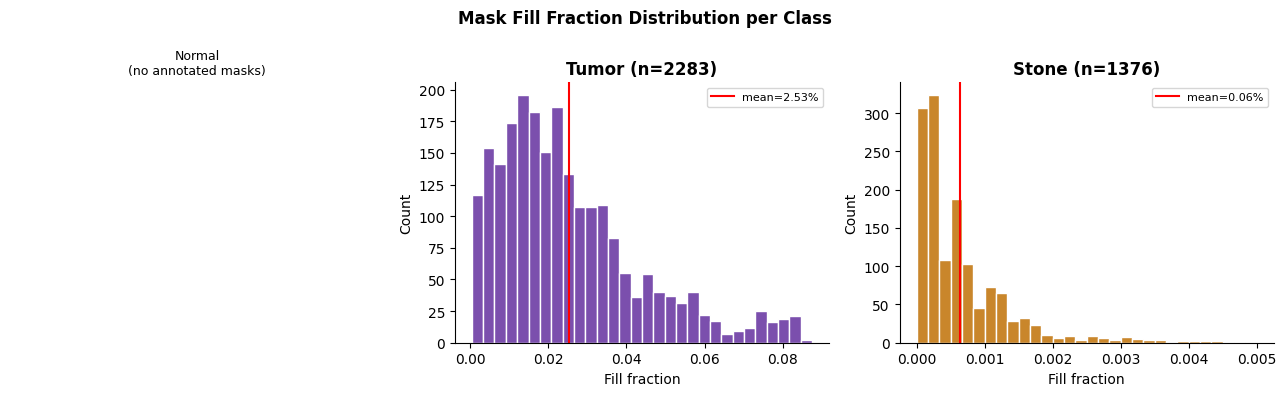

In [12]:
# Fill fraction distribution per class
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Mask Fill Fraction Distribution per Class', fontweight='bold')

colors = {'Normal': '#2E8B8B', 'Tumor': '#7B4FAD', 'Stone': '#C9862B'}
for ax, cls in zip(axes, CLASSES):
    sub = val_df[(val_df['class'] == cls) & (val_df['has_mask'])]
    if len(sub) == 0:
        ax.set_title(f'{cls}\n(no annotated masks)', fontsize=9)
        ax.axis('off')
        continue
    ax.hist(sub['fill_frac'], bins=30, color=colors[cls], edgecolor='white')
    ax.set_title(f'{cls} (n={len(sub)})', fontweight='bold')
    ax.set_xlabel('Fill fraction')
    ax.set_ylabel('Count')
    ax.axvline(sub['fill_frac'].mean(), color='red', lw=1.5,
               label=f'mean={sub["fill_frac"].mean():.2%}')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'mask_fill_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Visual QC — CT Image | RenSeg Annotation | Extracted Binary Mask

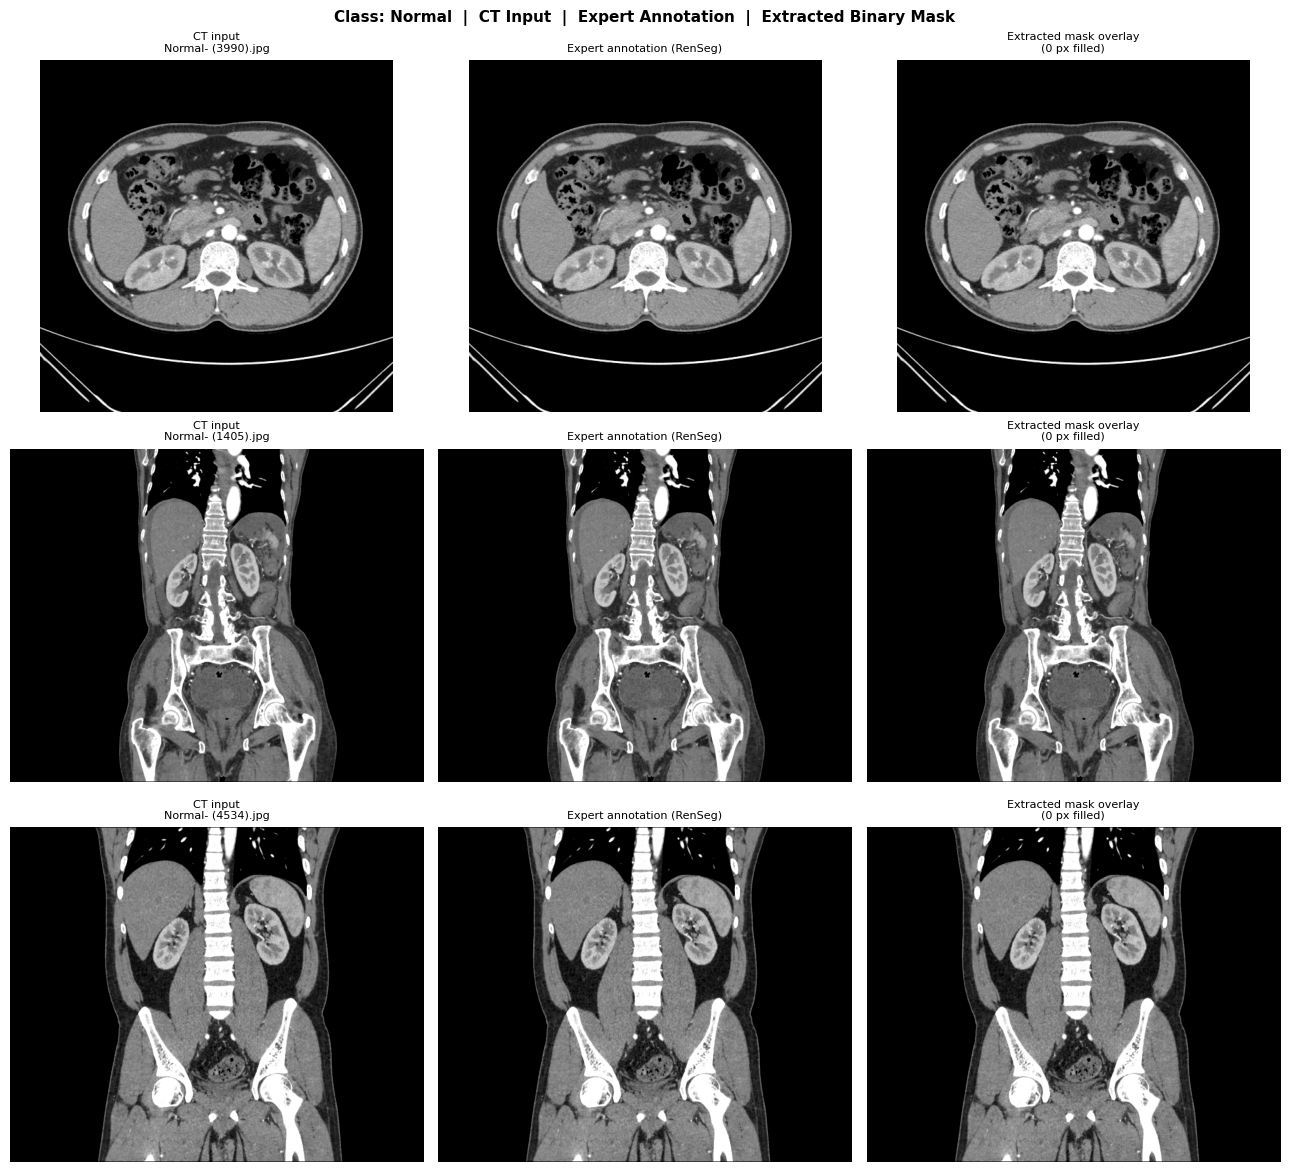

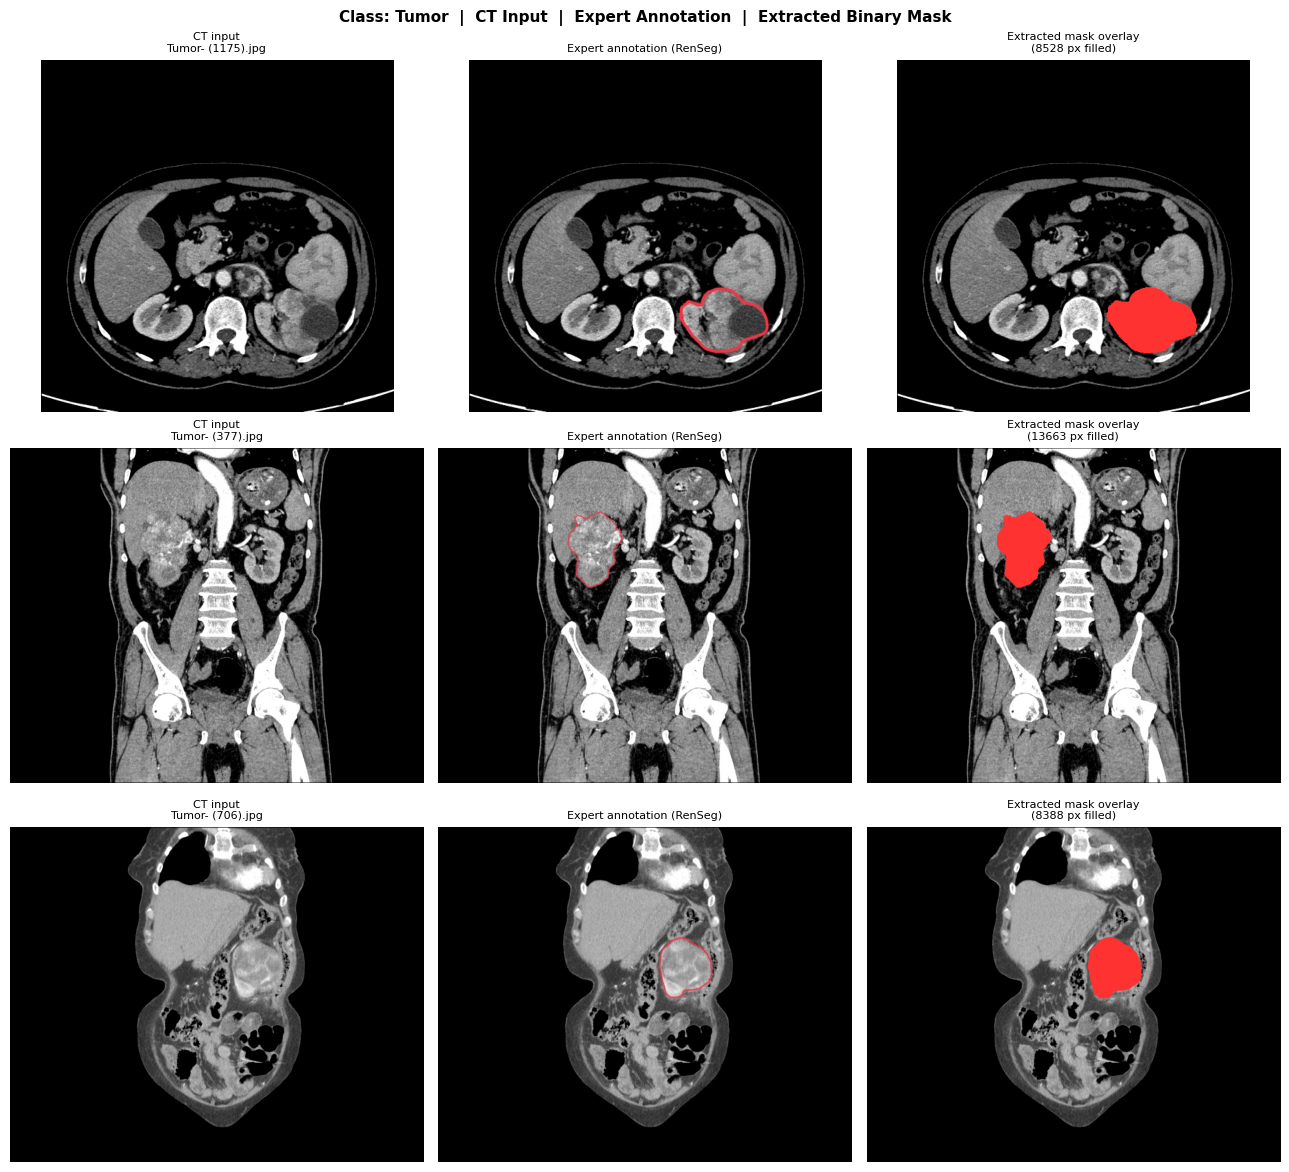

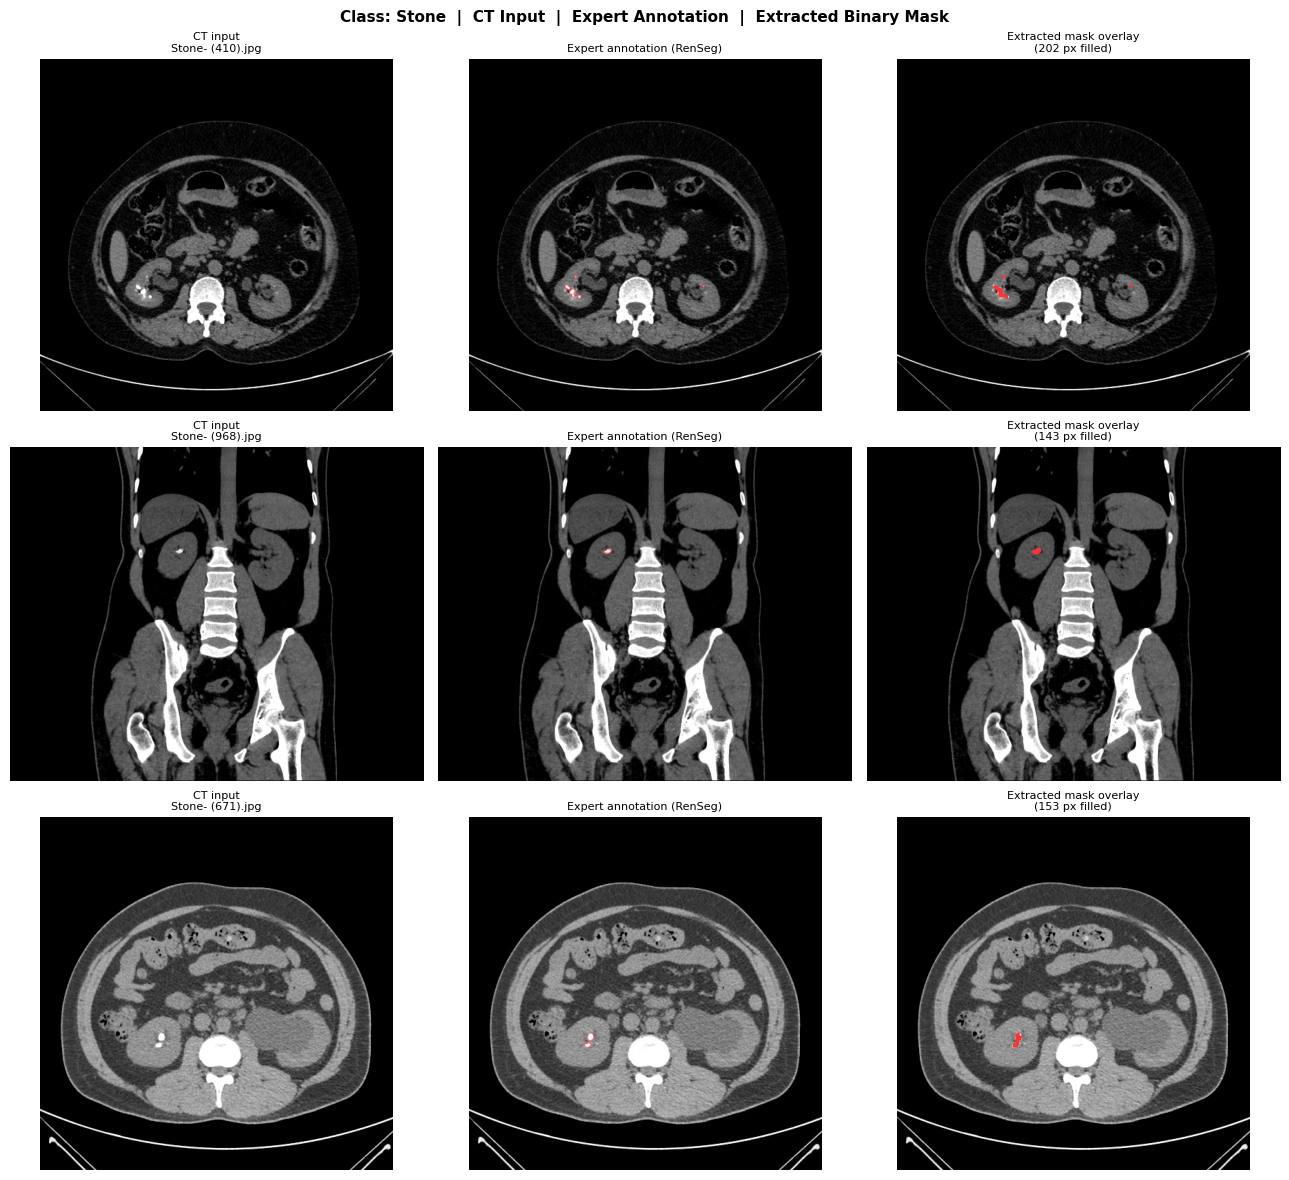

In [13]:
def show_triplet_qc(kaggle_files: dict, renseg_files: dict,
                     masks_root: Path, classes: list,
                     n_per_class: int = 3, seed: int = 42):
    """
    Show 3 columns per image:
    Kaggle (CT input) | RenSeg (annotated) | Extracted binary mask
    """
    rng = np.random.default_rng(seed)

    for cls in classes:
        k_files   = kaggle_files[cls]
        r_files   = renseg_files[cls]
        mask_dir  = masks_root / cls

        # prefer images that actually have a mask
        annotated = [
            i for i, p in enumerate(r_files)
            if (mask_dir / f'{p.stem}_mask.png').exists() and
               np.array(Image.open(mask_dir / f'{p.stem}_mask.png').convert('L')).sum() > 0
        ]

        pool  = annotated if annotated else list(range(len(k_files)))
        picks = rng.choice(pool, size=min(n_per_class, len(pool)), replace=False)

        fig, axes = plt.subplots(len(picks), 3, figsize=(13, len(picks) * 4))
        if len(picks) == 1: axes = axes[np.newaxis, :]
        fig.suptitle(
            f'Class: {cls}  |  CT Input  |  Expert Annotation  |  Extracted Binary Mask',
            fontsize=11, fontweight='bold'
        )

        for row, idx in enumerate(picks):
            k_img     = np.array(Image.open(k_files[idx]).convert('RGB'))
            r_img     = np.array(Image.open(r_files[idx]).convert('RGB'))
            mask_path = mask_dir / f'{r_files[idx].stem}_mask.png'
            mask      = np.array(Image.open(mask_path).convert('L')) \
                        if mask_path.exists() else np.zeros(k_img.shape[:2], dtype=np.uint8)

            # col 0 — Kaggle CT (model input)
            axes[row,0].imshow(k_img)
            axes[row,0].set_title(f'CT input\n{k_files[idx].name}', fontsize=8)
            axes[row,0].axis('off')

            # col 1 — RenSeg with expert red contour
            axes[row,1].imshow(r_img)
            axes[row,1].set_title('Expert annotation (RenSeg)', fontsize=8)
            axes[row,1].axis('off')

            # col 2 — extracted binary mask overlaid on CT
            # col 2 — extracted binary mask overlaid on CT
            overlay = k_img.copy()
            if (mask > 0).sum() > 0:
                overlay[mask > 0] = [255, 50, 50]
            axes[row,2].imshow(overlay)
            filled = (mask > 0).sum()
            axes[row,2].set_title(f'Extracted mask overlay\n({filled} px filled)', fontsize=8)
            axes[row,2].axis('off')

        plt.tight_layout()
        plt.savefig(REPORTS_DIR / f'qc_triplet_{cls}.png', dpi=130, bbox_inches='tight')
        plt.show()


show_triplet_qc(kaggle_files, renseg_files, MASKS_ROOT, CLASSES, n_per_class=3)

## 8. Final Summary

In [ ]:
header('Final Summary')

report = {
    'notebook'   : '01_dataset_and_mask_extraction',
    'kaggle_counts' : {c: len(kaggle_files[c]) for c in CLASSES},
    'renseg_counts' : {c: len(renseg_files[c]) for c in CLASSES},
    'mask_stats'    : mask_stats,
    'masks_output'  : str(MASKS_ROOT.resolve()),
}

with open(REPORTS_DIR / 'step01_report.json', 'w') as f:
    json.dump(report, f, indent=2)
ok('Report saved: data/processed/step01_report.json')

# summary table
rows = []
for cls in CLASSES:
    s = mask_stats.get(cls, {})
    rows.append([
        cls,
        len(kaggle_files[cls]),
        len(renseg_files[cls]),
        s.get('with_annotation', 0),
        s.get('empty_mask', 0),
    ])
rows.append([
    'TOTAL',
    sum(r[1] for r in rows[:-0] if isinstance(r[1], int)),
    sum(r[2] for r in rows[:-0] if isinstance(r[2], int)),
    sum(r[3] for r in rows[:-0] if isinstance(r[3], int)),
    sum(r[4] for r in rows[:-0] if isinstance(r[4], int)),
])

fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axis('off')
cols = ['Class', 'Kaggle (input)', 'RenSeg (GT)', 'Masks with annotation', 'Empty masks (Normal=OK)']
tbl  = ax.table(cellText=rows, colLabels=cols, cellLoc='center', loc='center',
                bbox=[0,0,1,1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for col in range(len(cols)):
    tbl[0, col].set_facecolor('#1B3A5C')
    tbl[0, col].set_text_props(color='white', fontweight='bold')
tbl[len(rows), 0].set_text_props(fontweight='bold')
plt.title('Step 01 — Summary', fontweight='bold', fontsize=12, pad=10)
plt.savefig(REPORTS_DIR / 'step01_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print()
ok('Notebook 01 complete.')
info('Binary masks saved to: data/processed/renseg_masks/')
info('Next → Notebook 02: SAM2 Pseudo-GT generation on Kaggle training images')